# 1. Introduction

This teaching notebook asks a retrospective question: using information recorded during a completed 2-year observation period, how well can a model rank records according to whether opioid use disorder (OUD) was documented in that same period?

The dataset column `OD` is retained for compatibility and records the OUD target. The model provides decision support for structured review. It is not a diagnostic system or an autonomous clinical decision-maker

Learning objectives:

1. Evaluate discrimination, calibration and errors without treating model associations or feature importance as causal effects
2. Translate a model alert into a defined, nonjudgmental clinical review workflow
3. Select an operating threshold from validation data using explicit capacity and harm assumptions, then evaluate it once on the test set

The dataset is synthetic and supports classroom analysis only. It does not establish clinical validity or performance for predicting future cases

Based on notebooks and documentation from the [Microsoft Responsible AI Toolbox](https://github.com/microsoft/responsible-ai-toolbox/tree/main/notebooks) and [scikit-learn probability calibration guidance](https://scikit-learn.org/stable/modules/calibration.html)

# 2. Data Set Characteristics

Number of records: 1,000 patient-level records

Number of columns used for modelling: 20 predictive attributes and 1 target column

Temporal interpretation for this exercise:

- Index date: end of the 2-year observation period
- Predictor window: the preceding 2 years
- Outcome recording: `OD` indicates whether OUD was documented in the same source 2-year period
- Limitation: the source does not establish that every predictor preceded the OUD diagnosis, so this is retrospective risk stratification rather than prediction of new future cases
- Prospective use would require a separate predictor window and future outcome horizon

Attribute information:

- `OD` target: records OUD documentation, where 1 = documented and 0 = not documented
- `Low_inc`: low income flag
- `Surgery`: major surgery recorded during the 2-year period
- `rx_ds`: cumulative opioid prescription days-supply filled during the 2-year period
- `A` to `V`: binary diagnosis or condition-group flags

`rx_ds` is a dispensing measure. It is not confirmed consumption or the number of unique calendar days of exposure. Values above 730 therefore do not mean more than 730 unique days exposed, and the source does not document whether overlapping prescriptions were deduplicated

# 3. Setup

- `responsibleai` and `raiwidgets` provide the Responsible Artificial Intelligence (RAI) dashboard components
- `fairlearn` provides group-performance metrics used in the later audit
- `dice-ml` supports counterfactual analysis and `econml` supports causal inference

In [8]:
# Reserve names so later RAI cells have explicit placeholders
train_df_rai = None
test_df_rai = None
feature_metadata = None

# Import core analysis libraries
from pathlib import Path
from datetime import datetime
import numpy as np
from numpy import percentile
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
from IPython.display import display, Markdown

# Import scikit-learn tools used for splitting, preprocessing, modelling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    f1_score,
)

# Optional libraries used by later Responsible Artificial Intelligence analyses
try:
    import dice_ml  # counterfactual library
    _DICE = True
except Exception:
    _DICE = False

try:
    import econml  # causal library
    _ECONML = True
except Exception:
    _ECONML = False

# Import course helpers for scores, evaluation, policy analysis and plots
from utils import (
    positive_scores,
    auc_report,
    tradeoff_table,
    pick_threshold_cost,
    pick_threshold_recall_floor,
    pick_threshold_workload,
    summary_at_threshold,
    wilson_interval,
    plot_recall_floor_curves,
    plot_cumulative_recall_at_threshold,
    plot_topk_at_threshold,
    make_thresholded_estimator,
    init_rai_dependencies,
)

# Check optional dashboard and Responsible Artificial Intelligence dependencies
rai_flags, rai_objects = init_rai_dependencies()
globals().update(rai_flags)
globals().update(rai_objects)

# Fix randomness for reproducible splits, jitter, and model fitting
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Report optional component availability without stopping the core analysis
print(
    f"Available components: RAI dashboard={_RAI}, "
    f"interpretability={_INTERPRET}, error analysis={_ERRANALYSIS}, "
    f"fairness metrics={_FAIRLEARN}, counterfactuals={_DICE}, "
    f"causal inference={_ECONML}"
)

Available components: RAI dashboard=True, interpretability=True, error analysis=True, fairness metrics=True, counterfactuals=True, causal inference=True


# 4. Data Load & preparation

In [2]:
# Load the supplied CSV; keep the raw column names for the first inspection
DATA_PATH = "./Data/opiod_raw_data.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"Raw data: {df_raw.shape[0]:,} records and {df_raw.shape[1]} columns")
display(
    df_raw.head().style
    .hide(axis="index")
)

Raw data: 1,000 records and 22 columns


ID,OD,Low_inc,SURG,rx ds,A,B,C,D,E,F,H,I,J,K,L,M,N,R,S,T,V
1,1,1,0,516,0,0,0,1,0,1,1,1,0,1,1,1,0,1,0,0,0
2,1,1,0,119,0,0,1,0,0,1,1,1,1,0,0,1,1,1,1,0,0
3,1,1,1,925,1,1,0,1,1,0,1,1,0,0,0,1,0,1,0,1,0
4,0,1,0,393,1,1,0,0,0,1,1,0,0,1,1,1,0,1,1,1,0
5,1,1,0,630,0,0,0,0,1,1,1,0,0,0,0,1,1,1,0,0,0


In [3]:
# Define the target using the dataset column name retained for code compatibility

TARGET = "OD"  # dataset column: 1 = recorded OUD diagnosis, 0 = not recorded

counts = df_raw[TARGET].value_counts(dropna=False)
prevalence_percent = counts.get(1, 0) / counts.sum() * 100
positives_per_1000 = counts.get(1, 0) / counts.sum() * 1000

print("Recorded OUD counts:")
print(counts.rename(index={0: "No recorded OUD", 1: "Recorded OUD"}).to_string())
print(f"\nRecorded OUD prevalence: {prevalence_percent:.2f}%")
print(f"Records with documented OUD per 1,000: {positives_per_1000:.1f}")

Recorded OUD counts:
No recorded OUD    819
Recorded OUD       181

Recorded OUD prevalence: 18.10%
Records with documented OUD per 1,000: 181.0


## 4.1. Basic cleaning, provenance and schema alignment

The supplied file is synthetic and contains one row per record. The analysis treats all predictors as available for scoring at the end of the 2-year observation period, while acknowledging that their order relative to OUD documentation is unknown

In [4]:
# Work on a copy so the raw file remains unchanged
df = df_raw.copy()

# Standardize names for the analysis code
df.columns = [c.strip().replace(" ", "_").replace("-", "_") for c in df.columns]

# Drop the identifier explicitly because it identifies the record rather than describing it
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# Accept the known raw alias without changing the source file
if "SURG" in df.columns and "Surgery" not in df.columns:
    df = df.rename(columns={"SURG": "Surgery"})

# Check that every predictor expected by the workflow is present
expected_cols = [
    "OD", "Low_inc", "Surgery", "rx_ds",
    "A", "B", "C", "D", "E", "F", "H", "I", "J", "K", "L", "M", "N", "R", "S", "T", "V"
]
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")


def to_binary(s: pd.Series) -> pd.Series:
    if s.dtype == "O":
        mapped = s.astype(str).str.strip().str.lower().map({
            "1": 1, "0": 0, "y": 1, "n": 0,
            "yes": 1, "no": 0, "true": 1, "false": 0
        })
        return pd.to_numeric(mapped, errors="coerce")
    return pd.to_numeric(s, errors="coerce")


# Convert binary flags to numeric 0/1 values and keep rx_ds numeric
binary_candidates = [c for c in expected_cols if c != "rx_ds"]
df[binary_candidates] = df[binary_candidates].apply(to_binary)
df["rx_ds"] = pd.to_numeric(df["rx_ds"], errors="coerce")

rx_over_730 = int((df["rx_ds"] > 730).sum())
data_audit = pd.DataFrame({
    "Measure": [
        "Records",
        "Missing cells",
        "Repeated analysis rows",
        "Minimum rx_ds (days-supply)",
        "Maximum rx_ds (days-supply)",
        "Records with rx_ds > 730",
    ],
    "Value": [
        len(df),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        float(df["rx_ds"].min()),
        float(df["rx_ds"].max()),
        rx_over_730,
    ],
    "Interpretation": [
        "Synthetic patient-level records",
        "After schema alignment",
        "Rows with identical analysis values after ID removal",
        "Lowest cumulative prescription days-supply filled",
        "Highest cumulative prescription days-supply filled",
        "Does not imply more than 730 unique days exposed",
    ],
})
display(
    data_audit.style
    .hide(axis="index")
    .format({"Value": "{:,.0f}"})
)

display(
    df.head().style
    .hide(axis="index")
)

Measure,Value,Interpretation
Records,"1,000",Synthetic patient-level records
Missing cells,0,After schema alignment
Repeated analysis rows,3,Rows with identical analysis values after ID removal
Minimum rx_ds (days-supply),0,Lowest cumulative prescription days-supply filled
Maximum rx_ds (days-supply),"1,923",Highest cumulative prescription days-supply filled
Records with rx_ds > 730,204,Does not imply more than 730 unique days exposed


OD,Low_inc,Surgery,rx_ds,A,B,C,D,E,F,H,I,J,K,L,M,N,R,S,T,V
1,1,0,516,0,0,0,1,0,1,1,1,0,1,1,1,0,1,0,0,0
1,1,0,119,0,0,1,0,0,1,1,1,1,0,0,1,1,1,1,0,0
1,1,1,925,1,1,0,1,1,0,1,1,0,0,0,1,0,1,0,1,0
0,1,0,393,1,1,0,0,0,1,1,0,0,1,1,1,0,1,1,1,0
1,1,0,630,0,0,0,0,1,1,1,0,0,0,0,1,1,1,0,0,0


**So what?** Structural checks improve confidence in the input, but they do not resolve the temporal limitations of this retrospective design

# 5. Training, Validation and Testing - 70/15/15 stratified split

- Training set: fit model parameters
- Validation set: inspect model behaviour, assess calibration and choose the threshold policy
- Test set: one final evaluation after the model and policy are locked

Training teaches the model. Validation is where we examine model behaviour and choose the operating policy. The test set is opened only after both are locked

The test outcomes remain closed while the model and policy are developed. The final test split still contains few recorded OUD cases, so final rates need raw counts and uncertainty intervals

**So what?** Keeping the test set untouched prevents model and policy choices from quietly adapting to the final evaluation

In [5]:
# Identify the target and the numeric predictor
target_col = "OD"
num_cols = ["rx_ds"]

# Infer binary predictors from their observed values
binary_cols = [col for col in df.columns
               if col not in [target_col] + num_cols
               and set(df[col].dropna().unique()).issubset({0, 1})]

cat_like_binary_cols = binary_cols.copy()

X = df[num_cols + cat_like_binary_cols].copy()
y = df[target_col].copy()

# Hold out the final test set; do not inspect its labels during development
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# Split the temporary holdout equally into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)


def split_summary(name, X_part, y_part):
    counts = y_part.value_counts().reindex([0, 1], fill_value=0)
    return {
        "Set": name,
        "Records": len(y_part),
        "No recorded OUD": int(counts[0]),
        "Recorded OUD cases": int(counts[1]),
        "No recorded OUD rate": float(counts[0] / len(y_part)),
        "Recorded OUD rate": float(counts[1] / len(y_part)),
    }


# Display development counts and rates while test labels remain closed
info = [
    split_summary("Train", X_train, y_train),
    split_summary("Validation", X_val, y_val),
    split_summary("Overall", X, y),
]
df_info = pd.DataFrame(info)
display(
    df_info.style
    .hide(axis="index")
    .format({
        "No recorded OUD rate": "{:.3f}",
        "Recorded OUD rate": "{:.3f}",
    })
)
print(f"Test set reserved: {len(X_test)} records; test outcomes remain closed until final evaluation")

Set,Records,No recorded OUD,Recorded OUD cases,No recorded OUD rate,Recorded OUD rate
Train,700,573,127,0.819,0.181
Validation,150,123,27,0.820,0.180
Overall,1000,819,181,0.819,0.181


Test set reserved: 150 records; test outcomes remain closed until final evaluation


## 5.1. Modeling pipeline, training, and calibration

### Setting a baseline

A majority-class baseline shows the minimum a model must improve on. It also shows why the percentage of all records classified correctly can look high when most records have no recorded OUD

**Discrimination** describes how well scores separate records with and without recorded OUD.

**Receiver operating characteristic area under the curve (ROC AUC)**
- Summarizes how well scores separate recorded OUD cases from records without recorded OUD over all thresholds
- Read it in the context of this validation population and its uncertainty, not with universal quality labels

**Calibration** describes how closely predicted probabilities match observed frequencies.

**Precision-recall area under the curve (PR AUC)**
- Summarizes the trade-off between recall and precision as the threshold changes
- Compare it with recorded OUD prevalence because this measure depends on the outcome frequency

**Prevalence** is the proportion of records with recorded OUD

**Recall (also called sensitivity)** is the proportion of recorded OUD cases the model flags

**Precision** is the proportion of flagged records that have recorded OUD

**So what?** The percentage of all records classified correctly can look high when most records are negative, so compare it with prevalence, PR AUC, recall and precision

Dummy baseline
PR AUC: 0.180
ROC AUC: 0.500
Recorded OUD prevalence: 0.180
PR AUC relative to prevalence baseline: 1.00 times


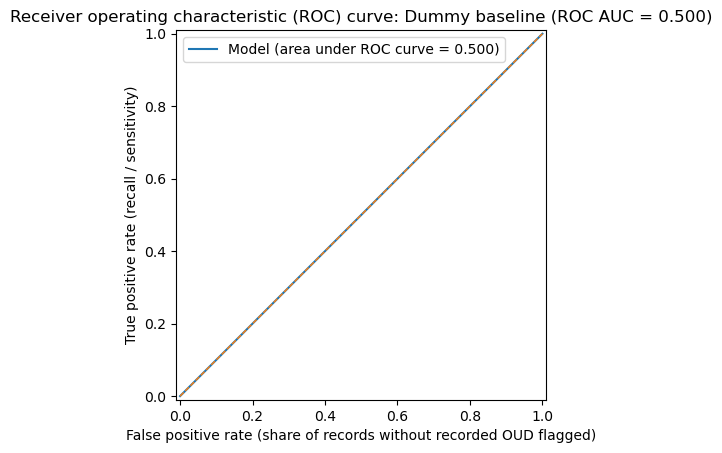

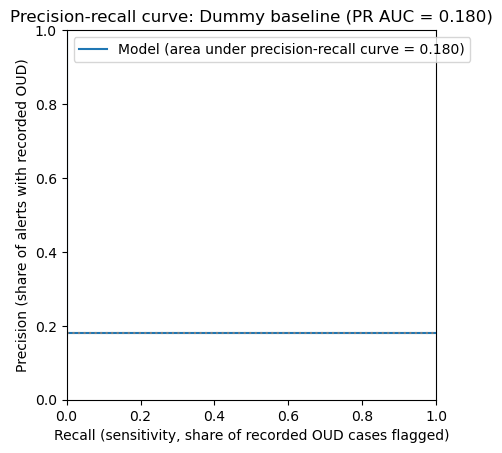

In [6]:
# Fit a majority-class baseline: it provides a simple reference point
dummy_clf = DummyClassifier(
    strategy="most_frequent", random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)

# Evaluate on validation data only
y_score_val = positive_scores(dummy_clf, X_val)
metrics_dummy = auc_report(
    y_val, y_score_val, name="Dummy baseline", plot=True)

## 5.2. Preprocesing our Pipeline

[Scikit-learn preprocessing](https://scikit-learn.org/stable/api/sklearn.preprocessing.html) turns raw columns into consistent model inputs. Here the pipeline fills missing values, standardizes numeric `rx_ds`, and applies a separate transformation to binary flags. Each transformation is fitted inside the training workflow so validation and test records use rules learned from training data

In [7]:
# Fit transformations inside the model pipeline so they learn only from training data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=True, with_std=True))
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("bin", binary_transformer, cat_like_binary_cols)
    ],
    remainder="drop",  # Use only the predictors listed above
    verbose_feature_names_out=False  # Keep original feature names in the output
)

# Use logistic regression as a transparent teaching baseline
base_clf = Pipeline(steps=[
    ("prep", preprocess),
    # Remove predictors with no variation in the training data
    ("varth", VarianceThreshold(threshold=0.0)),
    ("model", LogisticRegression(
        solver="liblinear",  # Stable solver for this small teaching example
        random_state=RANDOM_STATE,
        max_iter=200
    ))
])

### Basic preliminary model performance check

base_clf
PR AUC: 0.357
ROC AUC: 0.731
Recorded OUD prevalence: 0.180
PR AUC relative to prevalence baseline: 1.98 times


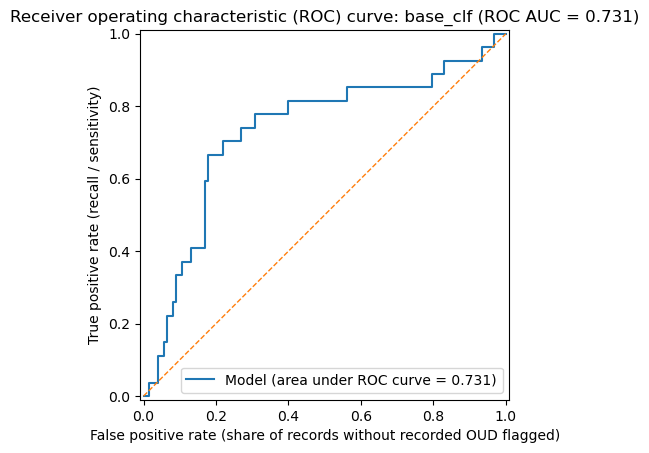

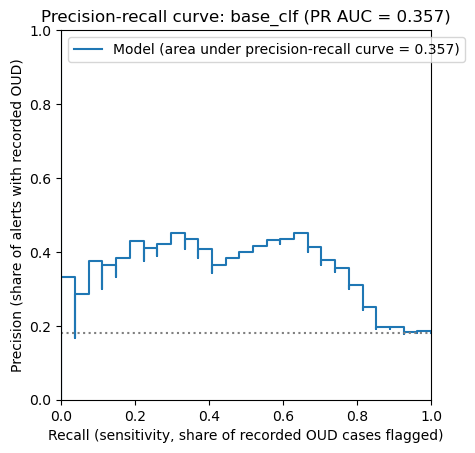

In [8]:
# Fit only on training data; validation remains an independent performance check
base_clf.fit(X_train, y_train)

# Evaluate on validation data only
y_score_val = positive_scores(base_clf, X_val)
metrics_base = auc_report(y_val, y_score_val, name="base_clf", plot=True)

### Interpreting the fitted logistic model before calibration

The table uses feature names after preprocessing and variance filtering. A coefficient is the signed weight the model assigns to a feature before calculating a probability. For a binary feature, the odds ratio compares the model-estimated odds when the feature changes from 0 to 1. `rx_ds` is standardized using the training data, so its odds ratio represents approximately a one-standard-deviation increase in cumulative prescription days-supply, not one additional prescription day. An odds ratio above 1 means the model assigns higher odds when the feature is present; below 1 means lower odds. These quantities describe patterns the model used in this dataset, not causal effects

In [9]:
# Extract coefficients from the fitted, uncalibrated logistic regression
preprocessor = base_clf.named_steps["prep"]
variance_filter = base_clf.named_steps["varth"]
logistic_model = base_clf.named_steps["model"]

feature_names_before_filter = np.asarray(preprocessor.get_feature_names_out())
retained_features = feature_names_before_filter[variance_filter.get_support()]
coefficients = logistic_model.coef_.ravel()

coefficient_table = pd.DataFrame({
    "Feature": retained_features,
    "Coefficient (model scale)": coefficients,
    "Odds ratio (exp(coefficient))": np.exp(coefficients),
    "Direction": np.where(
        coefficients > 0,
        "Higher model-estimated OUD odds",
        np.where(
            coefficients < 0,
            "Lower model-estimated OUD odds",
            "No directional change",
        ),
    ),
})
coefficient_table["absolute coefficient"] = coefficient_table["Coefficient (model scale)"].abs()
coefficient_table = (
    coefficient_table
    .sort_values("absolute coefficient", ascending=False)
    .drop(columns="absolute coefficient")
    .reset_index(drop=True)
)

display(
    coefficient_table.style
    .hide(axis="index")
    .format({
        "Coefficient (model scale)": "{:.3f}",
        "Odds ratio (exp(coefficient))": "{:.3f}",
    })
)

Feature,Coefficient (model scale),Odds ratio (exp(coefficient)),Direction
Low_inc,1.473,4.361,Higher model-estimated OUD odds
T,-0.665,0.515,Lower model-estimated OUD odds
R,-0.418,0.658,Lower model-estimated OUD odds
Surgery,0.332,1.394,Higher model-estimated OUD odds
C,0.300,1.350,Higher model-estimated OUD odds
E,0.265,1.303,Higher model-estimated OUD odds
B,-0.248,0.780,Lower model-estimated OUD odds
N,0.192,1.212,Higher model-estimated OUD odds
rx_ds,0.165,1.179,Higher model-estimated OUD odds
J,0.162,1.176,Higher model-estimated OUD odds


**So what?** Logistic regression lets us inspect which recorded features move the model score up or down, but these coefficients describe model associations, not what would happen if a patient's care changed

In [10]:
# Show a small validation sample: compare a raw score, an alert rule and the recorded outcome

tbl5 = (
    pd.DataFrame(
        {
            "raw_score": positive_scores(base_clf, X_val),
            "actual": y_val.loc[X_val.index].astype(int),
        },
        index=X_val.index,
    )
    .assign(predicted=lambda d: (d["raw_score"] >= 0.50).astype(int))  # Illustrative threshold before calibration
    .round({"raw_score": 3})
    .sample(n=10, random_state=7)
    .reset_index()
    .rename(columns={
        "index": "Validation record",
        "raw_score": "Uncalibrated model score",
        "predicted": "Alert at threshold 0.50",
        "actual": "Recorded OUD",
    })
    .loc[:, [
        "Validation record",
        "Uncalibrated model score",
        "Alert at threshold 0.50",
        "Recorded OUD",
    ]]
)

display(
    tbl5.style
    .hide(axis="index")
)

Validation record,Uncalibrated model score,Alert at threshold 0.50,Recorded OUD
94,0.130000,0,0
165,0.147000,0,0
996,0.125000,0,0
256,0.137000,0,0
854,0.109000,0,0
876,0.155000,0,0
401,0.500000,1,0
158,0.119000,0,0
2,0.253000,0,1
897,0.073000,0,1


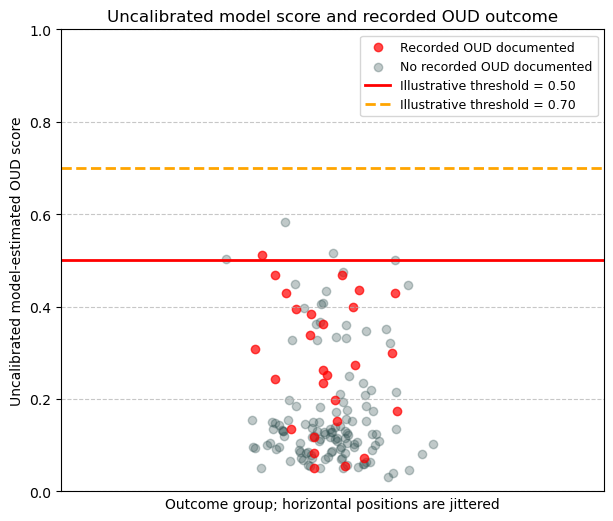

In [11]:
# Compare validation scores with the recorded OUD outcome
scores = positive_scores(base_clf, X_val)
actuals = y_val

# Separate scores for records with and without recorded OUD
scores_positive = scores[actuals == 1]
scores_negative = scores[actuals == 0]

# Jitter horizontal positions because the x-axis represents outcome groups, not a measured quantity
jitter_strength = 0.03
jitter_positive = np.random.normal(0, jitter_strength, len(scores_positive))
jitter_negative = np.random.normal(0, jitter_strength, len(scores_negative))

fig, ax = plt.subplots(figsize=(7, 6))
scatter_other = ax.scatter(jitter_negative, scores_negative, color="darkslategrey", alpha=0.3, label="No recorded OUD documented")
scatter_target = ax.scatter(jitter_positive, scores_positive, color="red", alpha=0.7, label="Recorded OUD documented")

# Add illustrative threshold lines; these are not the locked policy threshold
line_50 = ax.axhline(y=0.5, color="red", linestyle="-", linewidth=2, label="Illustrative threshold = 0.50")
line_70 = ax.axhline(y=0.7, color="orange", linestyle="--", linewidth=2, label="Illustrative threshold = 0.70")

ax.set_title("Uncalibrated model score and recorded OUD outcome")
ax.set_xlabel("Outcome group; horizontal positions are jittered")
ax.set_ylabel("Uncalibrated model-estimated OUD score")
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_xlim(-0.2, 0.2)  # Keep the visual spread fixed across reruns
ax.legend(handles=[scatter_target, scatter_other, line_50, line_70], fontsize=9, loc="upper right")

ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 6. Recalibrating the Scores

Calibration checks whether predicted probabilities match observed frequencies. For example, among records given a predicted probability near 0.30, about 30% would have the recorded outcome in a sufficiently large comparable group. Calibration changes the probability scale using cross-validation on training data only. It does not guarantee an individual outcome

The calibration-in-the-large check asks whether the average predicted probability matches the observed recorded OUD prevalence. If a model predicts an average risk of 30% in a group where about 18% have the recorded outcome, its scores are systematically too high even if its ranking is useful

The reliability plot compares predicted probabilities with observed outcome rates across equal-count risk bands. The Brier score is the mean squared difference between a predicted probability and the observed outcome. Log loss penalizes wrong and overconfident probabilities. These measures provide complementary validation evidence for this synthetic teaching example, not a claim of clinical safety or trust. See the [scikit-learn calibration documentation](https://scikit-learn.org/stable/modules/calibration.html)

In [12]:
# Use five-fold cross-validation within training data to fit the probability calibrator
calibrated_clf = CalibratedClassifierCV(
    estimator=base_clf,
    method="sigmoid",
    cv=5
)
calibrated_clf.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('prep',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['rx_ds']),
                                                                                  ('bin',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='most_frequent'))]),
                                                                                   ['Low_inc',
                                                                                    'Surgery',
                                                                                    'A',
                                                                                    'B',
                                                                                    'C',
                                                                                    'D',
                                                                                    'E',
                                                                                    'F',
                                                                                    'H',
                                                                                    'I',
                                                                                    'J',
                                                                                    'K',
                                                                                    'L',
                                                                                    'M',
                                                                                    'N',
                                                                                    'R',
                                                                                    'S',
                                                                                    'T',
                                                                                    'V'])],
                                                                    verbose_feature_names_out=False)),
                                                 ('varth', VarianceThreshold()),
                                                 ('model',
                                                  LogisticRegression(max_iter=200,
                                                                     random_state=42,
                                                                     solver='liblinear'))]))

Observed OUD prevalence,Mean raw predicted probability,Mean calibrated predicted probability,Absolute difference (calibrated mean vs observed)
0.180,0.186,0.185,0.005


"Risk band (Q1 = lowest, Q10 = highest)",Records in band,Mean raw predicted probability,Observed OUD prevalence,Mean calibrated predicted probability
Q1,15,0.052000,0.133000,0.077000
Q2,15,0.074000,0.133000,0.098000
Q3,15,0.093000,0.000000,0.115000
Q4,15,0.109000,0.000000,0.130000
Q5,15,0.126000,0.067000,0.143000
Q6,15,0.142000,0.067000,0.156000
Q7,15,0.174000,0.200000,0.180000
Q8,15,0.258000,0.467000,0.241000
Q9,15,0.364000,0.333000,0.316000
Q10,15,0.470000,0.400000,0.394000


Risk-band table includes 150 of 150 validation records


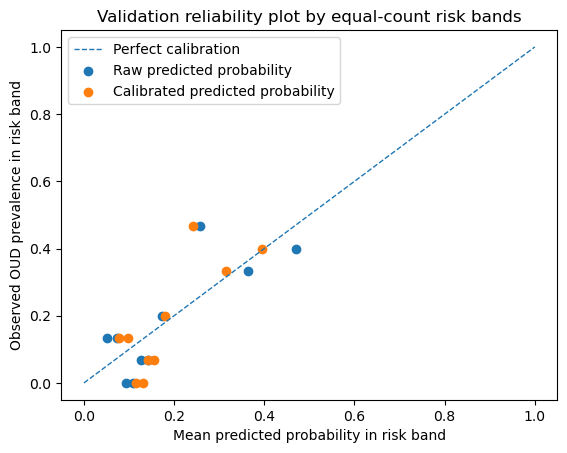

In [13]:
# Evaluate calibration on validation data only; keep the test set closed
base_clf_uncal = clone(base_clf).fit(X_train, y_train)
p_before = base_clf_uncal.predict_proba(X_val)[:, 1]
p_after = calibrated_clf.predict_proba(X_val)[:, 1]

df_cal = pd.DataFrame({
    "Recorded_OUD": y_val.values,
    "Pred_before": p_before,
    "Pred_after": p_after,
}, index=X_val.index)

observed_prevalence = float(df_cal["Recorded_OUD"].mean())
mean_raw_predicted = float(df_cal["Pred_before"].mean())
mean_calibrated_predicted = float(df_cal["Pred_after"].mean())
calibration_in_the_large_table = pd.DataFrame([{
    "Observed OUD prevalence": observed_prevalence,
    "Mean raw predicted probability": mean_raw_predicted,
    "Mean calibrated predicted probability": mean_calibrated_predicted,
    "Absolute difference (calibrated mean vs observed)": abs(
        mean_calibrated_predicted - observed_prevalence
    ),
}])
display(
    calibration_in_the_large_table.style
    .hide(axis="index")
    .format({column: "{:.3f}" for column in calibration_in_the_large_table.columns})
)

df_cal["Risk_band"] = pd.qcut(
    df_cal["Pred_after"], q=10,
    labels=[f"Q{i}" for i in range(1, 11)],
    duplicates="drop",
)

calibration_summary = (
    df_cal.groupby("Risk_band", observed=True)
    .agg(
        Records=("Recorded_OUD", "size"),
        Avg_pred_before=("Pred_before", "mean"),
        Observed_OUD_rate=("Recorded_OUD", "mean"),
        Avg_pred_after=("Pred_after", "mean"),
    )
    .reset_index()
    .round(3)
)
calibration_summary_display = calibration_summary.rename(columns={
    "Risk_band": "Risk band (Q1 = lowest, Q10 = highest)",
    "Records": "Records in band",
    "Avg_pred_before": "Mean raw predicted probability",
    "Observed_OUD_rate": "Observed OUD prevalence",
    "Avg_pred_after": "Mean calibrated predicted probability",
})
display(
    calibration_summary_display.style
    .hide(axis="index")
)
print(f"Risk-band table includes {int(calibration_summary['Records'].sum())} of {len(X_val)} validation records")

plt.figure()
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Perfect calibration")
plt.scatter(
    calibration_summary["Avg_pred_before"],
    calibration_summary["Observed_OUD_rate"],
    label="Raw predicted probability",
)
plt.scatter(
    calibration_summary["Avg_pred_after"],
    calibration_summary["Observed_OUD_rate"],
    label="Calibrated predicted probability",
)
plt.xlabel("Mean predicted probability in risk band")
plt.ylabel("Observed OUD prevalence in risk band")
plt.title("Validation reliability plot by equal-count risk bands")
plt.legend()
plt.show()

### Compare base_clf vs calibrated_clf on validation

In [14]:
# Compare ranking ability and probability scoring on validation data

# Obtain uncalibrated and calibrated scores
y_score_val_base = positive_scores(base_clf, X_val)
y_score_val_cal = positive_scores(calibrated_clf, X_val)

# Compare discrimination: how well scores separate the two recorded-outcome groups
roc_base = roc_auc_score(y_val, y_score_val_base)
pr_base = average_precision_score(y_val, y_score_val_base)
roc_cal = roc_auc_score(y_val, y_score_val_cal)
pr_cal = average_precision_score(y_val, y_score_val_cal)

# Compare probability scoring: whether probabilities are useful and not overconfident
ll_base = log_loss(y_val, np.clip(y_score_val_base, 1e-6, 1 - 1e-6))
ll_cal = log_loss(y_val, np.clip(y_score_val_cal,  1e-6, 1 - 1e-6))
brier_base = brier_score_loss(y_val, y_score_val_base)
brier_cal = brier_score_loss(y_val, y_score_val_cal)

# Assemble a readable comparison table
metrics_df = pd.DataFrame([
    {"Metric": "ROC AUC", "Uncalibrated": roc_base, "Calibrated": roc_cal, "Explanation": "How well scores separate recorded OUD from no recorded OUD across thresholds"},
    {"Metric": "PR AUC", "Uncalibrated": pr_base, "Calibrated": pr_cal, "Explanation": "How precision and recall trade off across thresholds; compare with prevalence"},
    {"Metric": "Log loss", "Uncalibrated": ll_base, "Calibrated": ll_cal, "Explanation": "Penalizes wrong and overconfident probabilities; lower is better"},
    {"Metric": "Brier score", "Uncalibrated": brier_base, "Calibrated": brier_cal, "Explanation": "Mean squared difference between predicted probability and outcome; lower is better"},
])

display(
    metrics_df.style
    .hide(axis="index")
    .format({"Uncalibrated": "{:.3f}", "Calibrated": "{:.3f}"})
)

Metric,Uncalibrated,Calibrated,Explanation
ROC AUC,0.731,0.736,How well scores separate recorded OUD from no recorded OUD across thresholds
PR AUC,0.357,0.356,How precision and recall trade off across thresholds; compare with prevalence
Log loss,0.421,0.423,Penalizes wrong and overconfident probabilities; lower is better
Brier score,0.131,0.133,Mean squared difference between predicted probability and outcome; lower is better


**So what?** Calibration matters because the threshold turns a model score into an alert for structured clinical review. Better-calibrated probabilities make that score easier to interpret, but they do not choose the policy threshold

# 7. Choosing when a predicted probability triggers a clinical review

A threshold is the probability cutoff used to turn a model score into an alert

Hypothetical teaching workflow:

`model-estimated risk alert -> structured clinician review -> clinical assessment or specialist consultation/referral if warranted`

The user is a prescribing clinician or relevant clinical team. Before the next relevant opioid-care or prescribing decision, the team reviews the person's history, diagnoses, comorbidities and clinical context, then discusses concerns through nonjudgmental shared decision-making. The alert is a model prediction, not a diagnosis of OUD. It must not automatically deny treatment, taper medication or discontinue care. Accountability remains with the clinician or clinical team

This workflow is illustrative and has not been clinically validated. It follows the [United States Food and Drug Administration transparency principles](https://www.fda.gov/medical-devices/software-medical-device-samd/transparency-machine-learning-enabled-medical-devices-guiding-principles), which emphasize intended users, workflow, outputs and limitations

Alert threshold,Recorded OUD cases correctly flagged,Alerts on records without recorded OUD,Missed recorded OUD cases,Recall (sensitivity),Precision,Alert count,"Alerts per 1,000 records"
0.000000,27,123,0,1.000,0.180,150,1000.0
0.096080,25,105,2,0.926,0.192,130,866.7
0.118316,23,86,4,0.852,0.211,109,726.7
0.140955,23,63,4,0.852,0.267,86,573.3
0.158940,22,43,5,0.815,0.338,65,433.3
0.211839,18,25,9,0.667,0.419,43,286.7
0.314996,9,13,18,0.333,0.409,22,146.7
1.000000,0,0,27,0.000,0.000,0,0.0


Distinct validation thresholds checked: 151


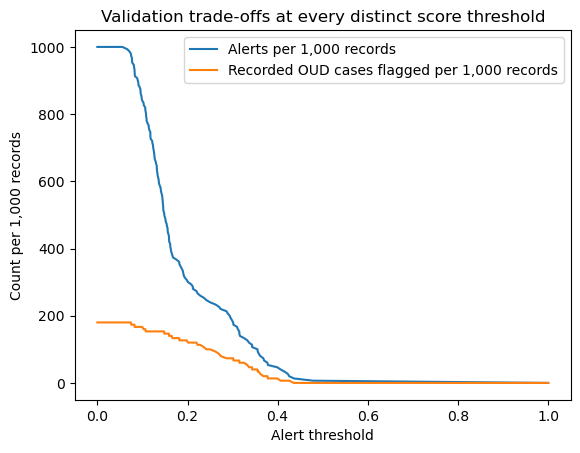

In [15]:
# Calculate validation scores and evaluate every distinct candidate threshold
y_score_val = positive_scores(calibrated_clf, X_val)
# A threshold changes classifications only when it crosses a distinct model score
df_thr = tradeoff_table(y_val, y_score_val, thresholds=None)
df_thr["alert_count"] = df_thr["TP"] + df_thr["FP"]

# Translate internal confusion-count names into plain-English display labels
THRESHOLD_DISPLAY_LABELS = {
    "threshold": "Alert threshold",
    "TP": "Recorded OUD cases correctly flagged",
    "FP": "Alerts on records without recorded OUD",
    "TN": "Records correctly not flagged",
    "FN": "Missed recorded OUD cases",
    "recall": "Recall (sensitivity)",
    "precision": "Precision",
    "alert_count": "Alert count",
    "alerts_per_1000": "Alerts per 1,000 records",
    "true_pos_per_1000": "Recorded OUD cases flagged per 1,000 records",
    "FN:FP harm ratio": "False-negative:false-positive harm ratio",
    "total harm points": "Total illustrative harm points",
}

candidate_preview_indices = np.unique(
    np.linspace(0, len(df_thr) - 1, min(8, len(df_thr)), dtype=int)
)
candidate_preview = (
    df_thr.iloc[candidate_preview_indices]
    .loc[:, ["threshold", "TP", "FP", "FN", "recall", "precision", "alert_count", "alerts_per_1000"]]
    .rename(columns=THRESHOLD_DISPLAY_LABELS)
)
display(
    candidate_preview.style
    .hide(axis="index")
    .format({
        "Alert threshold": "{:.6f}",
        "Recall (sensitivity)": "{:.3f}",
        "Precision": "{:.3f}",
        "Alerts per 1,000 records": "{:.1f}",
    })
)
print(f"Distinct validation thresholds checked: {len(df_thr)}")

plt.figure()
plt.plot(df_thr["threshold"], df_thr["alerts_per_1000"], label="Alerts per 1,000 records")
plt.plot(df_thr["threshold"], df_thr["true_pos_per_1000"], label="Recorded OUD cases flagged per 1,000 records")
plt.xlabel("Alert threshold")
plt.ylabel("Count per 1,000 records")
plt.title("Validation trade-offs at every distinct score threshold")
plt.legend()
plt.show()

## 7.1. Three separate threshold analyses

Thresholds encode policy choices rather than purely technical choices. We examine three distinct questions on validation data:

1. Workload analysis: what threshold stays within 300 alerts per 1,000 records?
2. Recall-floor analysis: what threshold reaches the illustrative 60% validation recall target with highest precision?
3. Harm sensitivity analysis: how does the preferred threshold change when a false negative receives 2, 5 or 10 harm points for every 1 false-positive harm point?

The primary rule later combines only the approved capacity and recall constraints, then selects the feasible threshold with highest precision. No test result contributes to that choice

A threshold changes classifications only when it crosses a distinct model score. The exact candidate table therefore evaluates 0, each unique validation probability and 1 rather than an arbitrary 0.01 grid

In code, `TP`, `FP`, `TN` and `FN` are standard confusion-count shorthand. The displayed tables translate them into correctly flagged cases, alerts on records without recorded OUD, correctly unflagged records and missed recorded OUD cases

### 7.1.1. Workload-only analysis on validation

Illustrative capacity: no more than 300 alerts per 1,000 records. This analysis does not impose the recall target

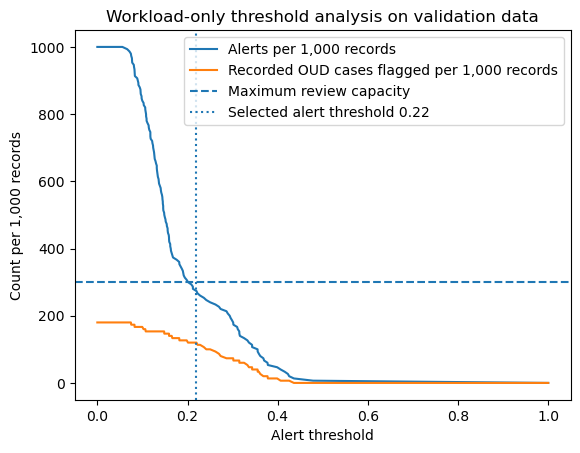

Alert threshold,Precision,Recall (sensitivity),Recorded OUD cases correctly flagged,Alerts on records without recorded OUD,Records correctly not flagged,Missed recorded OUD cases,"Alerts per 1,000 records","Recorded OUD cases flagged per 1,000 records"
0.220000,0.439000,0.667000,18,23,100,9,273.333000,120.000000


In [16]:
MAX_REVIEW_CAPACITY_PER_1000 = 300.0

workload_result = pick_threshold_workload(
    y_val, y_score_val, alerts_per_1000_max=MAX_REVIEW_CAPACITY_PER_1000
)
workload_table = workload_result["table"]
THR_WORKLOAD = float(workload_result["threshold"])

plt.figure()
plt.plot(workload_table["threshold"], workload_table["alerts_per_1000"], label="Alerts per 1,000 records")
plt.plot(workload_table["threshold"], workload_table["true_pos_per_1000"], label="Recorded OUD cases flagged per 1,000 records")
plt.axhline(MAX_REVIEW_CAPACITY_PER_1000, linestyle="--", label="Maximum review capacity")
plt.axvline(THR_WORKLOAD, linestyle=":", label=f"Selected alert threshold {THR_WORKLOAD:.2f}")
plt.xlabel("Alert threshold")
plt.ylabel("Count per 1,000 records")
plt.title("Workload-only threshold analysis on validation data")
plt.legend()
plt.show()

display(
    summary_at_threshold(y_val, y_score_val, THR_WORKLOAD)
    .rename(columns=THRESHOLD_DISPLAY_LABELS)
    .round(3)
    .style
    .hide(axis="index")
)

Risk bands group records with similar model-estimated risk. The next cell shows those bands and the overall score distribution; set `THR` to add a threshold line

Risk band (1 = highest estimated risk),Records in band,Recorded OUD cases,Lowest calibrated model-estimated OUD risk,Highest calibrated model-estimated OUD risk,Observed OUD prevalence,Cumulative share of recorded OUD cases flagged,"Records per 1,000 if entire band reviewed","Recorded OUD cases per 1,000 if entire band reviewed"
1,15,6,0.355000,0.478000,0.400000,0.222000,100.000000,40.000000
2,15,5,0.294000,0.343000,0.333000,0.407000,100.000000,33.333000
3,15,7,0.201000,0.289000,0.467000,0.667000,100.000000,46.667000
4,15,3,0.163000,0.198000,0.200000,0.778000,100.000000,20.000000
5,15,1,0.149000,0.162000,0.067000,0.815000,100.000000,6.667000
6,15,1,0.136000,0.148000,0.067000,0.852000,100.000000,6.667000
7,15,0,0.124000,0.136000,0.000000,0.852000,100.000000,0.000000
8,15,0,0.108000,0.124000,0.000000,0.852000,100.000000,0.000000
9,15,2,0.090000,0.107000,0.133000,0.926000,100.000000,13.333000
10,15,2,0.056000,0.088000,0.133000,1.000000,100.000000,13.333000


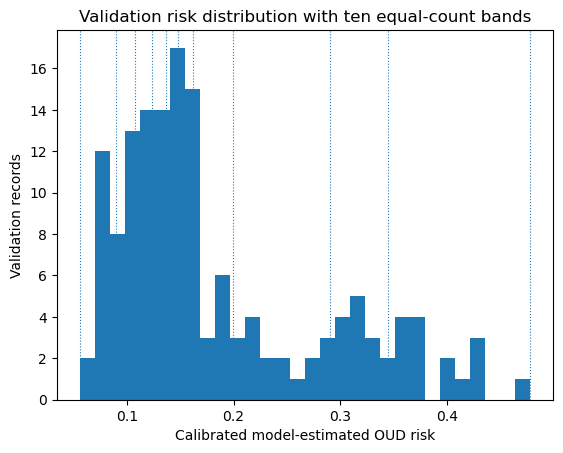

In [17]:
N_BINS = 10  # Create ten equal-count risk bands, also called deciles
y_score_val = positive_scores(calibrated_clf, X_val)

# Group validation records by score quantiles; band 1 is the highest-risk band
bands = pd.qcut(y_score_val, q=N_BINS, labels=False, duplicates="drop")
# qcut labels lowest=0 to highest=K-1, so invert the labels
bands = (bands.max() - bands) + 1

df = pd.DataFrame({
    "y_true": y_val.astype(int),
    "score": y_score_val,
    "band": bands.astype(int),
})

summ = (df.groupby("band", as_index=True)
          .agg(n=("y_true", "size"),
               positives=("y_true", "sum"),
               min_score=("score", "min"),
               max_score=("score", "max"))
          .sort_index())

summ["prevalence"] = summ["positives"] / summ["n"]
summ["cum_capture"] = summ["positives"].cumsum() / df["y_true"].sum()
summ["alerts_per_1000"] = 1000.0 * summ["n"] / len(df)
summ["true_pos_per_1000"] = 1000.0 * summ["positives"] / len(df)

risk_band_display = (
    summ.reset_index()
    .rename(columns={
        "band": "Risk band (1 = highest estimated risk)",
        "n": "Records in band",
        "positives": "Recorded OUD cases",
        "min_score": "Lowest calibrated model-estimated OUD risk",
        "max_score": "Highest calibrated model-estimated OUD risk",
        "prevalence": "Observed OUD prevalence",
        "cum_capture": "Cumulative share of recorded OUD cases flagged",
        "alerts_per_1000": "Records per 1,000 if entire band reviewed",
        "true_pos_per_1000": "Recorded OUD cases per 1,000 if entire band reviewed",
    })
    .round(3)
)
display(
    risk_band_display.style
    .hide(axis="index")
)

# Optional threshold overlay; leave THR=None when no overlay is needed
THR = None  # e.g., THR = 0.23

# Histogram of calibrated model-estimated risk with band boundaries
plt.figure()
plt.hist(df["score"], bins=30)
if THR is not None:
    plt.axvline(THR, linestyle="--")
edges = np.quantile(df["score"], np.linspace(0, 1, N_BINS + 1))
for x in edges:
    plt.axvline(x, linestyle=":", linewidth=0.8)
plt.xlabel("Calibrated model-estimated OUD risk")
plt.ylabel("Validation records")
plt.title("Validation risk distribution with ten equal-count bands")
plt.show()

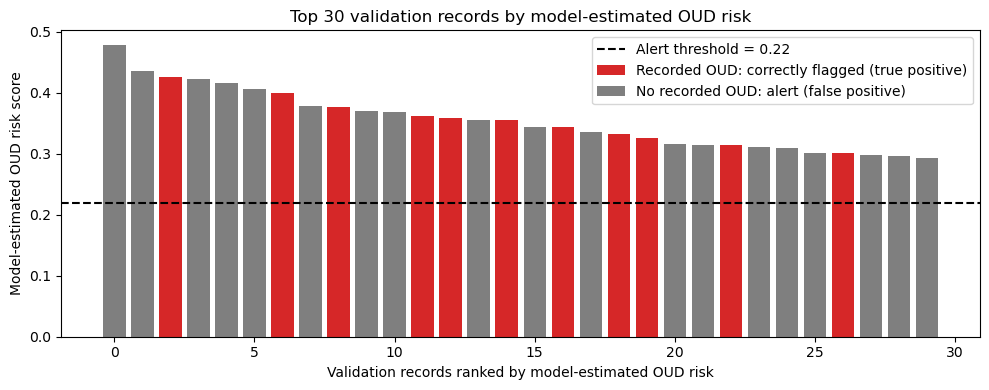

In [18]:
# Show the highest-scoring validation records at the workload-only threshold
plot_topk_at_threshold(y_val, y_score_val, chosen_threshold=THR_WORKLOAD, top_k=30)

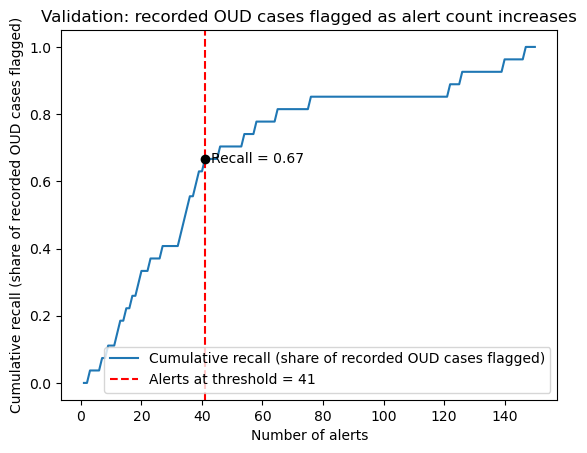

In [19]:
# Show how the cumulative share of recorded OUD cases flagged changes as alert count increases
plot_cumulative_recall_at_threshold(y_val, y_score_val, chosen_threshold=THR_WORKLOAD)

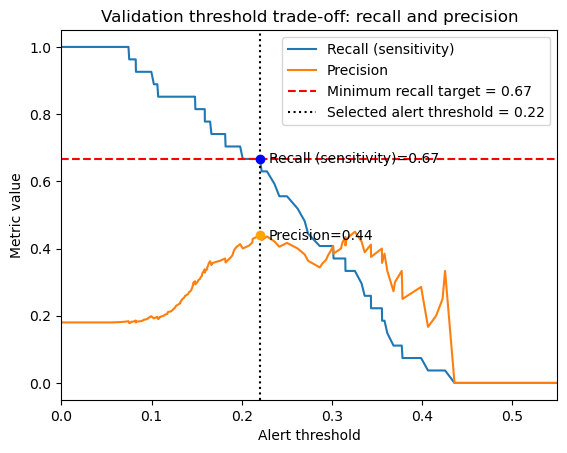

In [20]:
# Compare precision and recall at the workload-only threshold
workload_summary = summary_at_threshold(y_val, y_score_val, THR_WORKLOAD)
workload_recall = float(workload_summary["recall"].iloc[0])
plot_recall_floor_curves(y_val, y_score_val, recall_floor=workload_recall, chosen_threshold=THR_WORKLOAD)

### 7.1.2. Recall-floor-only analysis on validation

Here a recall floor means a minimum proportion of recorded OUD cases that the model should flag. The illustrative target is validation recall of at least 60%. Among thresholds meeting that target, this analysis selects the one with highest precision. Achieving the target on validation does not guarantee the same recall in new patients

Alert threshold,Precision,Recall (sensitivity),Recorded OUD cases correctly flagged,Alerts on records without recorded OUD,Records correctly not flagged,Missed recorded OUD cases,"Alerts per 1,000 records","Recorded OUD cases flagged per 1,000 records"
0.220000,0.439000,0.667000,18,23,100,9,273.333000,120.000000


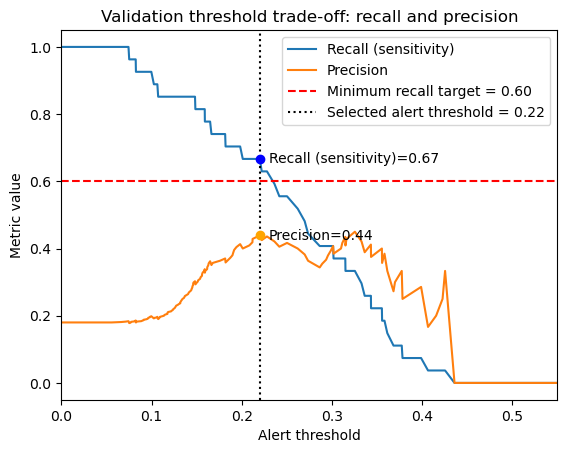

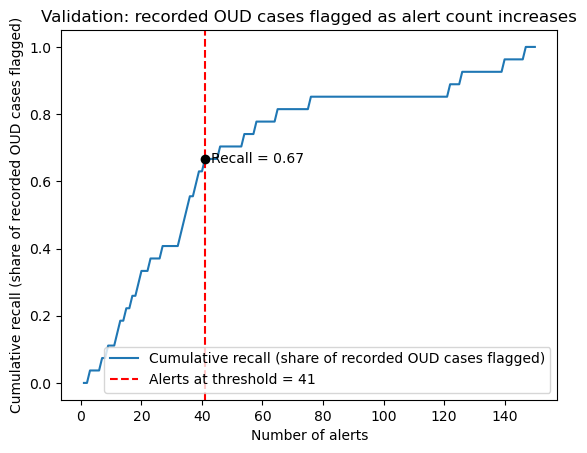

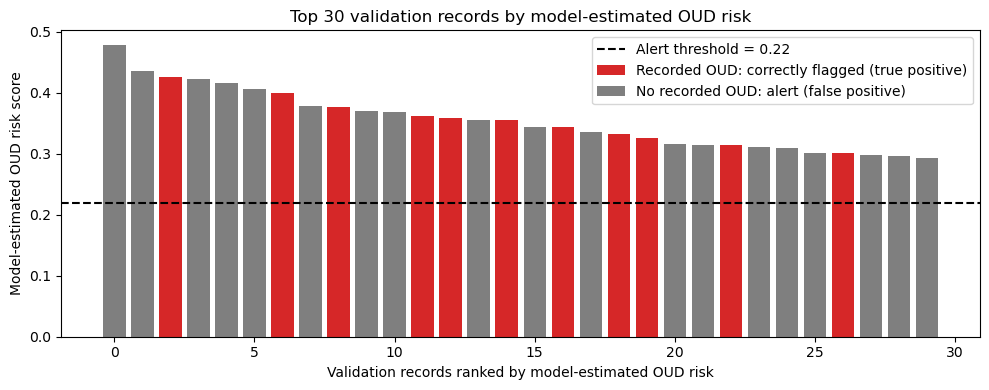

In [21]:
MIN_VALIDATION_RECALL = 0.60

recall_result = pick_threshold_recall_floor(
    y_val, y_score_val, recall_floor=MIN_VALIDATION_RECALL
)
THR_RECALL = float(recall_result["threshold"])

display(
    summary_at_threshold(y_val, y_score_val, THR_RECALL)
    .rename(columns=THRESHOLD_DISPLAY_LABELS)
    .round(3)
    .style
    .hide(axis="index")
)
plot_recall_floor_curves(
    y_val, y_score_val,
    recall_floor=MIN_VALIDATION_RECALL,
    chosen_threshold=THR_RECALL,
)
plot_cumulative_recall_at_threshold(y_val, y_score_val, chosen_threshold=THR_RECALL)
plot_topk_at_threshold(y_val, y_score_val, chosen_threshold=THR_RECALL, top_k=30)

### 7.1.3. Harm-point sensitivity analysis on validation

Harm points are illustrative academic inputs, not monetary costs or measured clinical utilities. A false positive is an alert for a record without recorded OUD and leads to an additional structured review, not automatic undertreatment. A false negative is a record with documented OUD that does not receive a model-triggered review. We test false-negative to false-positive ratios of 2:1, 5:1 and 10:1

In code, `TP`, `FP`, `TN` and `FN` are shorthand for correctly flagged recorded OUD cases, alerts on records without recorded OUD, correctly unflagged records and missed recorded OUD cases

In [22]:
# Compare illustrative false-negative to false-positive harm ratios on validation data
FP_HARM_POINTS = 1.0
FN_HARM_RATIOS = [2.0, 5.0, 10.0]

harm_rows = []
for fn_ratio in FN_HARM_RATIOS:
    harm_result = pick_threshold_cost(
        y_val, y_score_val,
        C_FP=FP_HARM_POINTS,
        C_FN=fn_ratio * FP_HARM_POINTS,
    )
    threshold = float(harm_result["threshold_empirical"])
    row = summary_at_threshold(y_val, y_score_val, threshold).iloc[0].to_dict()
    row.update({
        "FN:FP harm ratio": f"{fn_ratio:.0f}:1",
        "total harm points": FP_HARM_POINTS * row["FP"] + fn_ratio * FP_HARM_POINTS * row["FN"],
    })
    harm_rows.append(row)

harm_sensitivity = pd.DataFrame(harm_rows)[[
    "FN:FP harm ratio", "threshold", "TP", "FP", "FN", "recall",
    "precision", "alerts_per_1000", "total harm points"
]]
display(
    harm_sensitivity
    .rename(columns=THRESHOLD_DISPLAY_LABELS)
    .round(3)
    .style
    .hide(axis="index")
)

# Retain the approved 5:1 scenario for the sensitivity plot; it is not the governing rule
C_FP = FP_HARM_POINTS
C_FN = 5.0 * FP_HARM_POINTS
THR_HARM_5 = float(harm_sensitivity.loc[
    harm_sensitivity["FN:FP harm ratio"] == "5:1", "threshold"
].iloc[0])

False-negative:false-positive harm ratio,Alert threshold,Recorded OUD cases correctly flagged,Alerts on records without recorded OUD,Missed recorded OUD cases,Recall (sensitivity),Precision,"Alerts per 1,000 records",Total illustrative harm points
2:1,0.220000,18.000000,23.000000,9.000000,0.667000,0.439000,273.333000,41.000000
5:1,0.165000,21.000000,37.000000,6.000000,0.778000,0.362000,386.667000,67.000000
10:1,0.148000,23.000000,53.000000,4.000000,0.852000,0.303000,506.667000,93.000000


Validation sensitivity plot for the 5:1 harm ratio at threshold 0.16


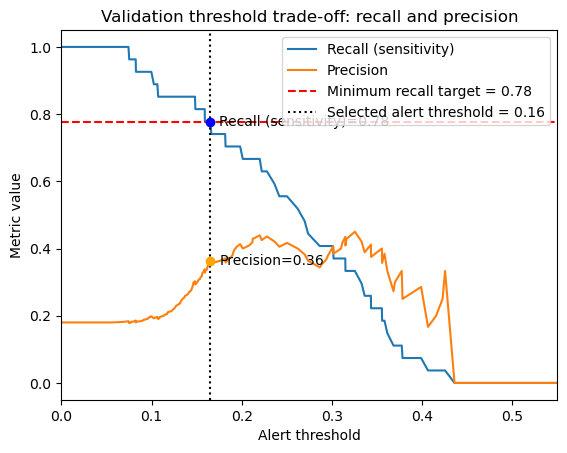

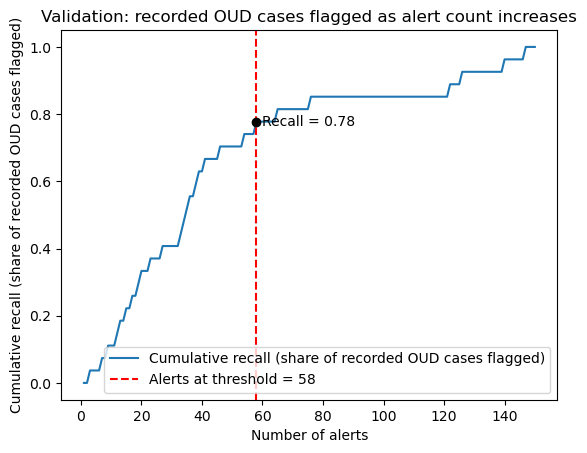

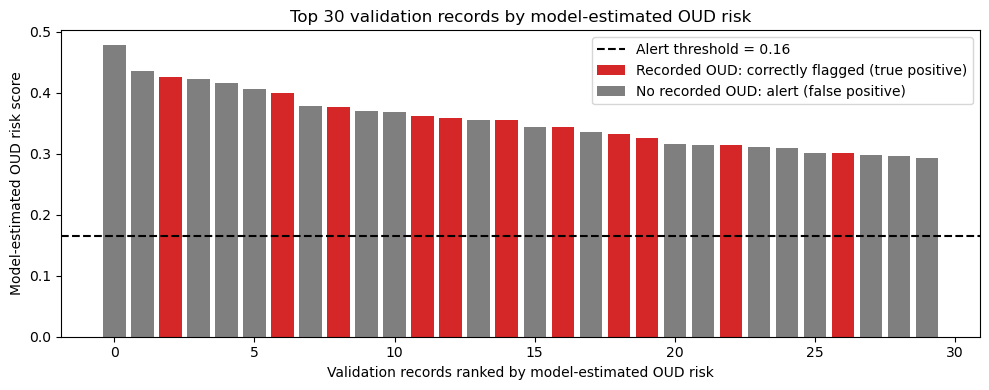

In [23]:
# Visualize the approved 5:1 harm scenario without making it the governing rule
harm_5_summary = summary_at_threshold(y_val, y_score_val, THR_HARM_5)
harm_5_recall = float(harm_5_summary["recall"].iloc[0])
print(f"Validation sensitivity plot for the 5:1 harm ratio at threshold {THR_HARM_5:.2f}")
plot_recall_floor_curves(
    y_val, y_score_val,
    recall_floor=harm_5_recall,
    chosen_threshold=THR_HARM_5,
)
plot_cumulative_recall_at_threshold(y_val, y_score_val, chosen_threshold=THR_HARM_5)
plot_topk_at_threshold(y_val, y_score_val, chosen_threshold=THR_HARM_5, top_k=30)

# 8. Freeze the Threshold Policy, Then Evaluate Once on Test

Primary validation-only rule:

1. Require recall of at least 60%
2. Require no more than 300 alerts per 1,000 records
3. Among feasible thresholds, select the one with highest precision
4. If none is feasible, report infeasibility rather than weakening the rule after viewing test results

The final threshold is frozen before any test prediction is calculated

| Analysis | Question answered | Role in policy decision |
| :--- | :--- | :--- |
| Workload only | Which threshold fits capacity? | Supporting analysis |
| Recall floor only | Which threshold meets the validation recall target with highest precision? | Supporting analysis |
| Harm sensitivity | How does the choice respond to assumed relative harms? | Sensitivity analysis |
| Joint primary rule | Which threshold meets both approved constraints and has highest precision? | Final validation-only selection rule |

The test set remains closed while the candidate table is filtered and ranked. Validation uncertainty describes how much results may vary because this teaching split contains a particular sample of records. The 60% recall value remains a policy target, not a promise of future performance

In [24]:
# Apply the primary policy rule to validation predictions only
policy_candidates = df_thr.copy()
policy_candidates["alert_count"] = policy_candidates["TP"] + policy_candidates["FP"]
feasible = policy_candidates[
    (policy_candidates["recall"] >= MIN_VALIDATION_RECALL)
    & (policy_candidates["alerts_per_1000"] <= MAX_REVIEW_CAPACITY_PER_1000)
].copy()

if feasible.empty:
    raise RuntimeError(
        "No validation threshold meets both the 60% recall target and "
        "the capacity of 300 alerts per 1,000 records"
    )

feasible = feasible.sort_values(
    ["precision", "threshold"], ascending=[False, False]
).reset_index(drop=True)
selected_validation = feasible.iloc[0].copy()
FINAL_THR = float(selected_validation["threshold"])
POLICY_LOCKED = True

val_recall_interval = wilson_interval(
    int(selected_validation["TP"]),
    int(selected_validation["TP"] + selected_validation["FN"]),
)
val_precision_interval = wilson_interval(
    int(selected_validation["TP"]),
    int(selected_validation["TP"] + selected_validation["FP"]),
)

validation_policy_table = pd.DataFrame([{
    "threshold": FINAL_THR,
    "validation n": len(y_val),
    "TP": int(selected_validation["TP"]),
    "FP": int(selected_validation["FP"]),
    "FN": int(selected_validation["FN"]),
    "recall": float(selected_validation["recall"]),
    "recall 95% confidence interval": f"{val_recall_interval[0]:.3f} to {val_recall_interval[1]:.3f}",
    "precision": float(selected_validation["precision"]),
    "precision 95% confidence interval": f"{val_precision_interval[0]:.3f} to {val_precision_interval[1]:.3f}",
    "alert count": int(selected_validation["alert_count"]),
    "alerts per 1,000": float(selected_validation["alerts_per_1000"]),
}])
validation_policy_display = validation_policy_table.rename(columns={
    "threshold": "Locked alert threshold",
    "validation n": "Validation records",
    "TP": "Recorded OUD cases correctly flagged",
    "FP": "Alerts on records without recorded OUD",
    "FN": "Missed recorded OUD cases",
    "recall": "Recall (sensitivity)",
    "recall 95% confidence interval": "Recall 95% confidence interval",
    "precision": "Precision",
    "precision 95% confidence interval": "Precision 95% confidence interval",
    "alert count": "Alert count",
    "alerts per 1,000": "Alerts per 1,000 records",
})
display(
    validation_policy_display.round(3)
    .style
    .hide(axis="index")
)
print(f"Primary threshold policy locked on validation at {FINAL_THR:.6f}")

Locked alert threshold,Validation records,Recorded OUD cases correctly flagged,Alerts on records without recorded OUD,Missed recorded OUD cases,Recall (sensitivity),Recall 95% confidence interval,Precision,Precision 95% confidence interval,Alert count,"Alerts per 1,000 records"
0.220000,150,18,23,9,0.667000,0.478 to 0.814,0.439000,0.299 to 0.590,41,273.333000


Primary threshold policy locked on validation at 0.219932


The selected threshold is derived from validation predictions. It is not entered manually and must not be changed after viewing test performance. We use precision to rank thresholds only after both the recall and capacity constraints are satisfied

**So what?** The threshold is a healthcare-policy choice reflecting review capacity and tolerance for missed cases, not an intrinsic property of the model

The harm-point results remain a sensitivity analysis. They do not replace the approved joint primary rule

In [25]:
selected = validation_policy_table.iloc[0]
validation_message = f"""
At the locked validation threshold of **{selected['threshold']:.2f}**, the model flags **{selected['alert count']:.0f} of {selected['validation n']:.0f} records** ({selected['alerts per 1,000']:.1f} per 1,000). It correctly flags **{selected['TP']:.0f} recorded OUD cases**, raises **{selected['FP']:.0f} alerts on records without recorded OUD** (false positives), and misses **{selected['FN']:.0f} recorded OUD cases** (false negatives). Validation recall (also called sensitivity) is **{selected['recall']:.3f}** (95% confidence interval {selected['recall 95% confidence interval']}) and precision is **{selected['precision']:.3f}** (95% confidence interval {selected['precision 95% confidence interval']}).

These estimates describe this synthetic validation sample and do not guarantee performance in new patients
"""
display(Markdown(validation_message))


At the locked validation threshold of **0.22**, the model flags **41 of 150 records** (273.3 per 1,000). It correctly flags **18 recorded OUD cases**, raises **23 alerts on records without recorded OUD** (false positives), and misses **9 recorded OUD cases** (false negatives). Validation recall (also called sensitivity) is **0.667** (95% confidence interval 0.478 to 0.814) and precision is **0.439** (95% confidence interval 0.299 to 0.590).

These estimates describe this synthetic validation sample and do not guarantee performance in new patients


## 8.1. One final test-set evaluation

The model and `FINAL_THR` are now locked. The next cell opens the test labels once to estimate final performance. No test result feeds back into model fitting, calibration or threshold selection

In [26]:
# Audit the policy lock before opening test labels; this cell uses validation objects only
assert POLICY_LOCKED is True
assert 0.0 <= FINAL_THR <= 1.0
assert float(selected_validation["recall"]) >= MIN_VALIDATION_RECALL
assert float(selected_validation["alerts_per_1000"]) <= MAX_REVIEW_CAPACITY_PER_1000

policy_lock = pd.DataFrame([{
    "policy selection data": "validation only",
    "locked threshold": FINAL_THR,
    "minimum validation recall": MIN_VALIDATION_RECALL,
    "maximum alerts per 1,000 records": MAX_REVIEW_CAPACITY_PER_1000,
    "selection rule": "highest precision among feasible thresholds",
}])
display(
    policy_lock.style
    .hide(axis="index")
)

policy selection data,locked threshold,minimum validation recall,"maximum alerts per 1,000 records",selection rule
validation only,0.219932,0.600000,300.000000,highest precision among feasible thresholds


Locked alert threshold,Test records,Recorded OUD cases in test set,Recorded OUD cases correctly flagged,Alerts on records without recorded OUD,Missed recorded OUD cases,Recall (sensitivity),Recall 95% confidence interval,Precision,Precision 95% confidence interval,Alert count,"Alerts per 1,000 records",ROC AUC,PR AUC
0.220000,150,27,20,34,7,0.741000,0.553 to 0.868,0.370000,0.254 to 0.504,54,360.000000,0.731000,0.405000


Final calibrated model on locked test set
PR AUC: 0.405
ROC AUC: 0.731
Recorded OUD prevalence: 0.180
PR AUC relative to prevalence baseline: 2.25 times


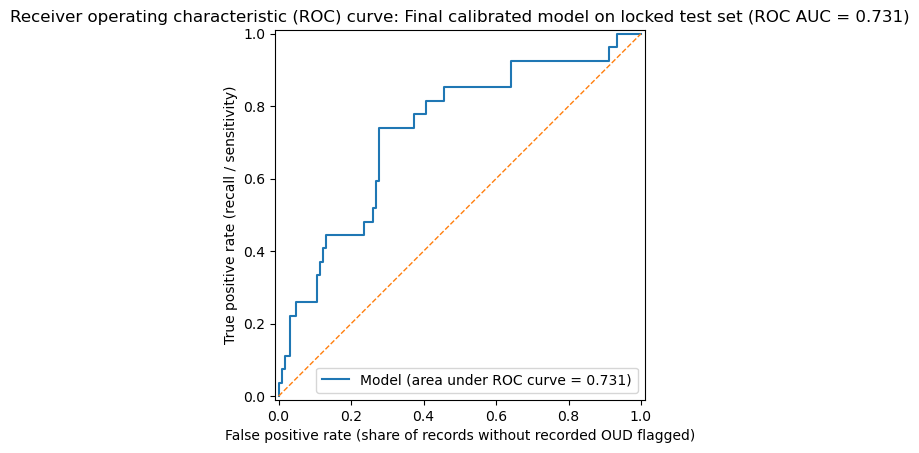

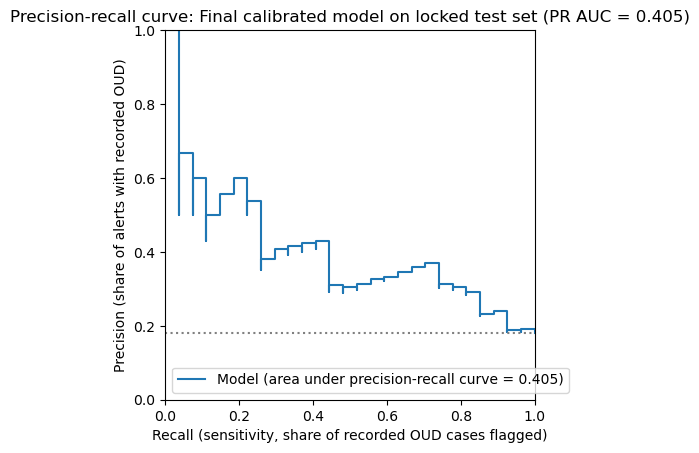

Final test results are estimates from 150 synthetic records and remain highly uncertain


In [27]:
# Perform one final test evaluation after the model and policy are locked
if not POLICY_LOCKED:
    raise RuntimeError("Threshold policy must be locked before test evaluation")

y_score_test = positive_scores(calibrated_clf, X_test)
test_summary = summary_at_threshold(y_test, y_score_test, FINAL_THR).iloc[0]

test_recall_interval = wilson_interval(
    int(test_summary["TP"]), int(test_summary["TP"] + test_summary["FN"])
)
test_precision_interval = wilson_interval(
    int(test_summary["TP"]), int(test_summary["TP"] + test_summary["FP"])
)

final_test_table = pd.DataFrame([{
    "locked threshold": FINAL_THR,
    "test n": len(y_test),
    "recorded OUD cases": int((y_test == 1).sum()),
    "TP": int(test_summary["TP"]),
    "FP": int(test_summary["FP"]),
    "FN": int(test_summary["FN"]),
    "recall": float(test_summary["recall"]),
    "recall 95% confidence interval": f"{test_recall_interval[0]:.3f} to {test_recall_interval[1]:.3f}",
    "precision": float(test_summary["precision"]),
    "precision 95% confidence interval": f"{test_precision_interval[0]:.3f} to {test_precision_interval[1]:.3f}",
    "alert count": int(test_summary["TP"] + test_summary["FP"]),
    "alerts per 1,000": float(test_summary["alerts_per_1000"]),
    "ROC AUC": float(roc_auc_score(y_test, y_score_test)),
    "PR AUC": float(average_precision_score(y_test, y_score_test)),
}])
final_test_display = final_test_table.rename(columns={
    "locked threshold": "Locked alert threshold",
    "test n": "Test records",
    "recorded OUD cases": "Recorded OUD cases in test set",
    "TP": "Recorded OUD cases correctly flagged",
    "FP": "Alerts on records without recorded OUD",
    "FN": "Missed recorded OUD cases",
    "recall": "Recall (sensitivity)",
    "recall 95% confidence interval": "Recall 95% confidence interval",
    "precision": "Precision",
    "precision 95% confidence interval": "Precision 95% confidence interval",
    "alert count": "Alert count",
    "alerts per 1,000": "Alerts per 1,000 records",
})
display(
    final_test_display.round(3)
    .style
    .hide(axis="index")
)

auc_report(
    y_true=y_test,
    y_score=y_score_test,
    name="Final calibrated model on locked test set",
)
print(f"Final test results are estimates from {len(y_test)} synthetic records and remain highly uncertain")

The final results support only a classroom demonstration of retrospective risk stratification. They do not validate prediction of future cases, diagnosis, treatment decisions or a real clinical pathway. Any prospective study would need temporally separated predictors and outcomes, external validation, workflow testing and governance review

**So what?** Final test metrics estimate performance after locking the model and policy, remain uncertain, and do not establish clinical validity

# 9. Intro to RAI toolkit

ROC AUC and PR AUC summarize important aspects of model performance, but they do not show the whole clinical-policy picture. Before considering any real clinical use, we would need evidence about intended use, workflow, errors, subgroup performance, uncertainty and monitoring. This teaching model is not validated for real-world clinical use

The Responsible Artificial Intelligence (RAI) toolkit helps us ask:

- **Interpretability:** Which recorded features contributed most to this model prediction?
- **Error analysis:** Where does the model make more mistakes, and for which records or groups?
- **Counterfactual analysis:** Which feature values would need to change for this model prediction to change? This describes model behaviour, not what would improve a person's health
- **Causal inference:** What evidence supports the claim that an intervention changes a real-world outcome? A dashboard estimate does not establish a causal effect on its own

Microsoft's [Responsible AI dashboard documentation](https://learn.microsoft.com/en-us/azure/machine-learning/concept-responsible-ai-dashboard?view=azureml-api-2) describes these components as complementary tools for understanding model behaviour, errors, subgroup performance and possible interventions

In this section, we will build the dashboard step by step for the calibrated model-estimated OUD risk:

1. Setup: prepare the data and model and initialize the main `RAIInsights` object
2. Add components: add interpretability, error analysis, counterfactual and causal-analysis tools
3. Compute and launch: run the analyses and launch the interactive dashboard

## 9.1 Setup: Creating the RAIInsights Object

1. Prepare data: the toolkit requires training and test data in pandas DataFrames, including features and the target
2. Describe feature roles: identify categorical variables and use `Low_inc` for an exploratory socioeconomic subgroup audit. The software parameter is called `identity_feature_name`, but that name is an interface label, not a claim that `Low_inc` represents an identity group
3. Preserve the policy: wrap the calibrated classifier in a helper that applies the threshold locked during validation while keeping probability outputs available for the dashboard

This setup creates an `RAIInsights` object, a container for the analytical components added next. The dashboard can describe model behaviour and subgroup patterns, but it does not turn a prediction into a diagnosis or a causal result

In [ ]:
# Define exactly the feature set used to train the model
feature_cols = list(X_train.columns)

# Create RAI-compatible DataFrames with features and the target column
target_col = TARGET
train_df_rai = X_train.copy()
train_df_rai[target_col] = y_train
test_df_rai = X_test.copy()
test_df_rai[target_col] = y_test

if "Surgery" in train_df_rai.columns:
    train_df_rai["Surgery"] = train_df_rai["Surgery"].astype(str)
    test_df_rai["Surgery"] = test_df_rai["Surgery"].astype(str)

# Describe categorical features and the exploratory socioeconomic subgroup
categorical_features = [c for c in cat_like_binary_cols if c in feature_cols]
if "Surgery" in feature_cols and "Surgery" not in categorical_features:
    categorical_features.append("Surgery")

identity_feature = "Low_inc" if "Low_inc" in feature_cols else None
feature_metadata = FeatureMetadata(
    identity_feature_name=identity_feature,
    categorical_features=categorical_features,
)

# Reuse the threshold locked by the joint validation policy
if not globals().get("POLICY_LOCKED", False):
    raise RuntimeError(
        "The upstream joint validation policy must be locked before RAI setup"
    )
locked_threshold = float(validation_policy_table["threshold"].iloc[0])
if not np.isclose(float(FINAL_THR), locked_threshold):
    raise RuntimeError(
        "FINAL_THR does not match the upstream locked validation policy threshold"
    )
print(f"Using the threshold locked by the joint validation rule: {FINAL_THR:.3f}")

# Wrap the classifier so binary predictions use the authoritative threshold
threshold_model = make_thresholded_estimator(calibrated_clf, threshold=FINAL_THR)

# Create the main RAIInsights object
rai_insights = RAIInsights(
    model=threshold_model,
    train=train_df_rai,
    test=test_df_rai,
    target_column=target_col,
    task_type="classification",
    feature_metadata=feature_metadata
)

## 9.2 Adding Analytical Components to the Dashboard

Each component answers a different practical question:

- **Interpretability (`.explainer`):** Which recorded features contributed most to an individual prediction or to the model's overall behaviour?
- **Error analysis (`.error_analysis`):** Where does the model make more mistakes, and which records or groups are affected?
- **Counterfactual analysis (`.counterfactual`):** What smallest permitted changes to the input would make the model produce a different prediction? This is a model-behaviour question, not evidence that changing the feature would improve an outcome
- **Causal inference (`.causal`):** What would historical data suggest about an intervention and a real-world outcome? A causal estimate depends on assumptions and is not established by adding a dashboard component

These views complement the validation and clinical-policy analysis in Sections 1 to 8. Interpretability explains model behaviour, counterfactual analysis explores model responses to changed inputs, and causal inference addresses a different question about real-world effects. The [Microsoft Responsible AI dashboard documentation](https://learn.microsoft.com/en-us/azure/machine-learning/concept-responsible-ai-dashboard?view=azureml-api-2) describes the distinction between these uses

In [ ]:
# Add the components needed to inspect predictions and error patterns
# Dashboard model-overview and data views are generated automatically
rai_insights.explainer.add()
rai_insights.error_analysis.add()

# Use the exact observed categories from training data for Surgery
surgery_categories = (
    train_df_rai["Surgery"].astype(str).dropna().unique().tolist()
    if "Surgery" in train_df_rai.columns else None
)

# Keep what-if values within the observed training-data range
permitted_range = {
    "rx_ds": [float(X_train["rx_ds"].min()), float(X_train["rx_ds"].max())],
    "Surgery": ["0", "1"]
}

if surgery_categories is not None:
    permitted_range["Surgery"] = sorted(surgery_categories)

features_to_vary = [
    "rx_ds", "Surgery"] if "Surgery" in feature_cols else ["rx_ds"]

# Generate model-level what-if examples within the permitted ranges
rai_insights.counterfactual.add(
    total_CFs=10,
    method="random",  # Generate random candidate changes within the allowed range
    desired_class="opposite",  # Ask for a different model class, not a different clinical outcome
    features_to_vary=features_to_vary,
    permitted_range=permitted_range
)

# Treat these variables as inputs for an exploratory causal analysis
# The code does not show that a provider can safely change them or that changing them changes an outcome
# Socioeconomic status and traumatic injury are not direct treatment levers in this dataset
treatment_features = ["Surgery", "rx_ds"]
rai_insights.causal.add(treatment_features=treatment_features)

print("Added interpretability, error analysis, counterfactual and causal-analysis components")

## 9.3 Compute Insights and Launch Dashboard

The next cell runs the selected analyses and then opens the interactive dashboard. The results help us inspect model behaviour, error patterns, what-if model responses and causal-analysis estimates under their assumptions

In [ ]:
# Run the selected analyses; the computation may take a few minutes
print("Computing RAI insights. Please wait")
rai_insights.compute()
print("Computation complete")

# Open the dashboard after computation
ResponsibleAIDashboard(rai_insights)